Build a model that will look at all 8 input columns and try to find the best weighed combination of them to predict target (house price).

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [4]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target


In [7]:
#model needs input column it learnes from (X) 
# and output column it's trying to predict (Y)

X =df.drop(columns=['target']) #everything except target
Y = df['target'] #only target column

In [8]:
#split into train and test sets

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 16512
Testing rows: 4128


In [ ]:
#train the model 

model = LinearRegression() #creates model object (algorithm)
model.fit(X_train, Y_train) 

print("Model trained successfuly")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_:.4f}")

Model trained successfuly
Coefficients: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Intercept: -37.0233


In [10]:
#make predictions and evaluate 

y_pred = model.predict(X_test)

mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared:          {r2:.4f}")

Mean Squared Error: 0.5559
R-squared:          0.5758


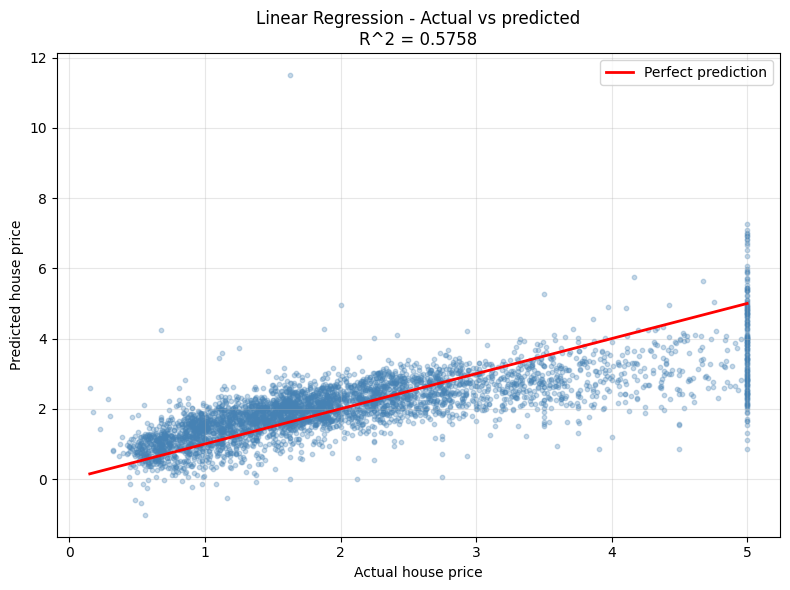

In [11]:
#plot 

plt.figure(figsize=(8, 6))
plt.scatter(Y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
        color='red', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual house price')
plt.ylabel('Predicted house price')
plt.title(f"Linear Regression - Actual vs predicted\nR^2 = {r2 :.4f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()